In [11]:
# importing libraries
import pandas as pd
import matplotlib.pyplot as plt

# loading dataset 
df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [12]:
# Basic info of the data
df.info()

#statistical summary
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [13]:
# finding missing values
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [14]:
df=df.drop_duplicates()

In [15]:
# Total Sales
Total_Sales=df['Sales'].sum()
print("Total_Sales:",Total_Sales)

Total_Sales: 2297200.8603


In [16]:
# Total Profit
Total_Profit=df['Profit'].sum()
print("Total_Profit:",Total_Profit)

Total_Profit: 286397.0217


In [18]:
# Profit by Category
round(df.groupby("Category")['Profit'].sum(),2)

Category
Furniture           18451.27
Office Supplies    122490.80
Technology         145454.95
Name: Profit, dtype: float64

In [19]:
# Top 5 profitable products
round(df.groupby("Product Name")['Profit'].sum().sort_values(ascending=False).head(5),2)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.93
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.04
Hewlett Packard LaserJet 3310 Copier                                            6983.88
Canon PC1060 Personal Laser Copier                                              4570.93
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.98
Name: Profit, dtype: float64

In [22]:
# Create Profit Margin column
df['Profit_Margin']=df['Profit']/df['Sales']

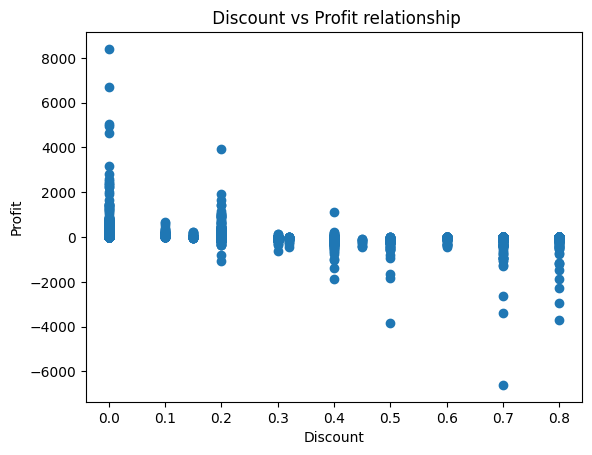

In [24]:
# Discount vs Profit relationship

plt.scatter(df['Discount'],df['Profit'])
plt.title(" Discount vs Profit relationship")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

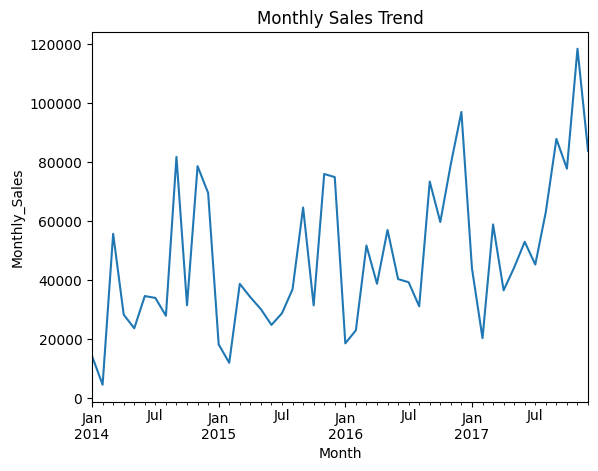

In [25]:
# Monthly Sales Trend
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Monthly_Sales")
plt.show()

In [26]:
# Top 10 Customer
Top_Customers=round(df.groupby("Customer Name")['Sales'].sum().sort_values(ascending=False),2)
print("Top_Customers:",Top_Customers.head(10))

Top_Customers: Customer Name
Sean Miller           25043.05
Tamara Chand          19052.22
Raymond Buch          15117.34
Tom Ashbrook          14595.62
Adrian Barton         14473.57
Ken Lonsdale          14175.23
Sanjit Chand          14142.33
Hunter Lopez          12873.30
Sanjit Engle          12209.44
Christopher Conant    12129.07
Name: Sales, dtype: float64


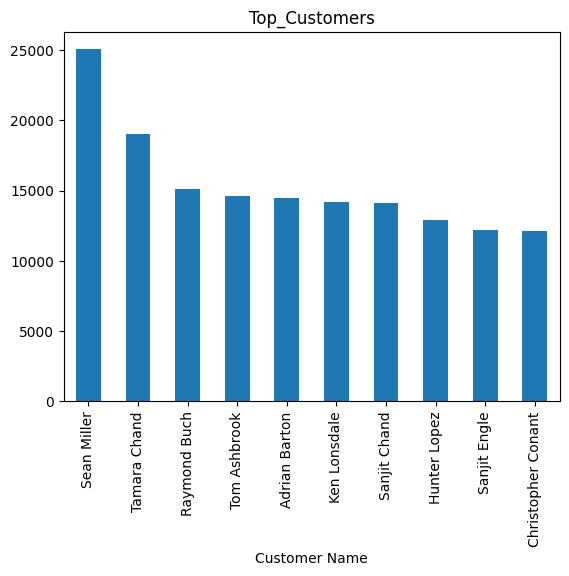

In [35]:
Top_Customers.head(10).plot(kind='bar')
plt.title("Top_Customers")
plt.show()

In [27]:
# Show all orders where company is making loss
loss_orders=df[df['Profit']<0]
print(loss_orders.head(5))

    Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
3        4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
14      15  US-2015-118983 2015-11-22 2015-11-26  Standard Class    HP-14815   
15      16  US-2015-118983 2015-11-22 2015-11-26  Standard Class    HP-14815   
23      24  US-2017-156909 2017-07-16 2017-07-18    Second Class    SF-20065   
27      28  US-2015-150630 2015-09-17 2015-09-21  Standard Class    TB-21520   

      Customer Name      Segment        Country             City  ...  \
3    Sean O'Donnell     Consumer  United States  Fort Lauderdale  ...   
14    Harold Pawlan  Home Office  United States       Fort Worth  ...   
15    Harold Pawlan  Home Office  United States       Fort Worth  ...   
23  Sandra Flanagan     Consumer  United States     Philadelphia  ...   
27  Tracy Blumstein     Consumer  United States     Philadelphia  ...   

     Region       Product ID         Category Sub-Category  \
3     South  FUR-T

In [28]:
# Count how many loss orders
print(len(loss_orders))

1871


In [31]:
# Find average sales per category
round(df.groupby("Category")['Sales'].mean(),2)

Category
Furniture          349.83
Office Supplies    119.32
Technology         452.71
Name: Sales, dtype: float64

In [32]:
# saving cleaned data 
df.to_csv("sale_data.csv", index=False)

In [ ]:
print(len(df))

9994


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')

Rows: 9994


In [37]:

# 🔹 Convert dates properly
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], errors='coerce')

In [38]:

# 🔹 Convert numeric
cols = ['Sales', 'Profit', 'Discount', 'Quantity']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [39]:

# 🔹 Remove bad rows
df = df.dropna(subset=['Sales', 'Profit'])

In [40]:
# 🔹 Create Profit_Margin
df['Profit_Margin'] = df['Profit'] / df['Sales']
df['Profit_Margin'] = df['Profit_Margin'].replace([np.inf, -np.inf], 0)

In [41]:
# 🔹 Convert DATE to STRING (VERY IMPORTANT 🔥)
df['Order_Date'] = df['Order_Date'].astype(str)
df['Ship_Date'] = df['Ship_Date'].astype(str)

In [42]:
# 🔹 Save final
df.to_csv("superstore_data.csv", index=False)

In [43]:
print("Rows:", len(df))

Rows: 9994
